In [1]:
from skimage.util import view_as_windows
import numpy as np

def get_positions(image_data, patch_size=16, stride=None):
    if stride is None:
        stride = patch_size

    blocks = view_as_windows(
        image_data,
        (patch_size, patch_size),
        step=stride
    )

    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * stride, j * stride)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions

def label_to_image(original_image, labels, positions, patch_size=16):
    H, W = original_image.shape[:2]

    label_img = np.zeros((H, W), dtype=np.uint8)
    vote_img  = np.zeros((H, W), dtype=np.uint8)

    for (r, c), lab in zip(positions, labels):
        r_end = min(r + patch_size, H)
        c_end = min(c + patch_size, W)

        region = (slice(r, r_end), slice(c, c_end))

        votes = vote_img[region] + 1

        mask = votes >= vote_img[region]

        label_patch = label_img[region]
        label_patch[mask] = lab

        vote_img[region][mask] = votes[mask]

    return label_img


In [24]:
from pathlib import Path
from ncempy.io import dm

base_dir = Path( "../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC")

image = base_dir / "20220202_Ag_UTC_330kx_2650e_0p1596s_05.dm3"

data_dict = dm.dmReader(str(Path(image).resolve()))
image = data_dict['data']

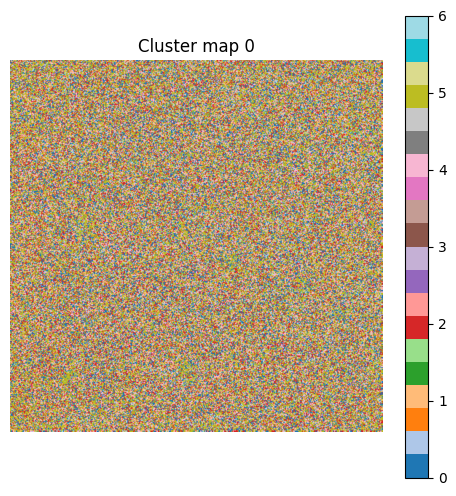

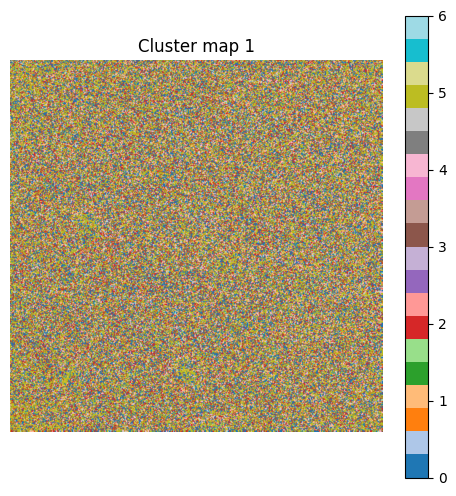

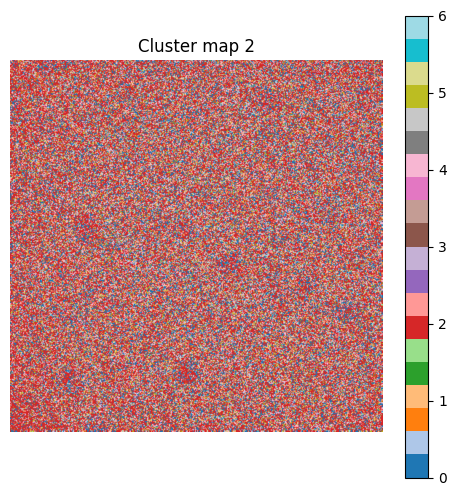

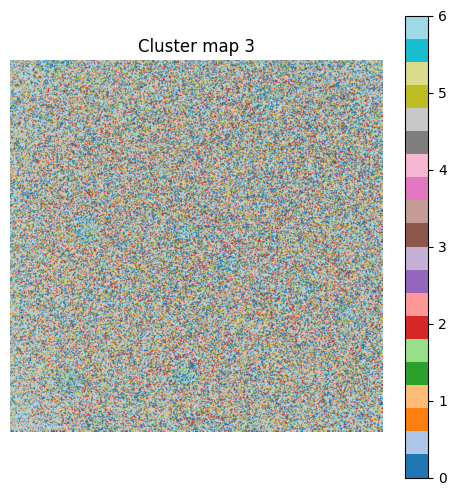

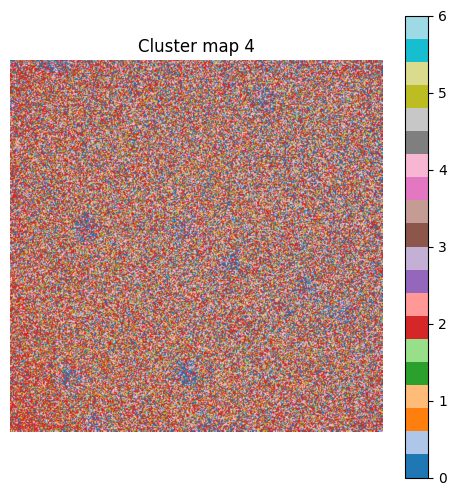

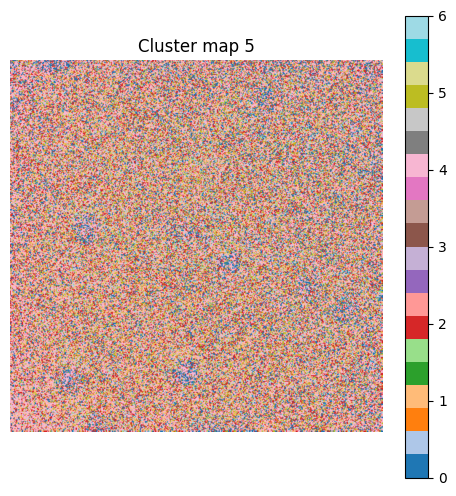

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("gaussian_filters_experiment.parquet")
for idx, row in df.iterrows():
    labels = row["clustered"]

    labels = np.array(labels).ravel()

    positions = get_positions(image, 16, 8)
    label_img = label_to_image(image, labels, positions)

    plt.figure(figsize=(6,6))
    plt.imshow(label_img, cmap="tab20")
    plt.title(f"Cluster map {idx}")
    plt.colorbar()
    plt.axis("off")
    plt.show()

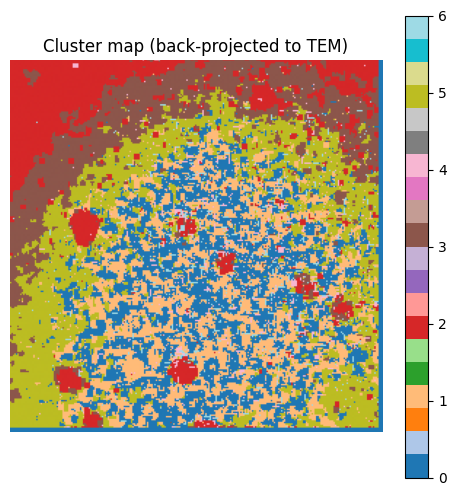

In [39]:
import pandas as pd

df_7_z = pd.read_parquet("larger_patch.parquet")

labels = df_7_z["clustered"].to_numpy().ravel()
positions = get_positions(image, 64, 16)
label_img = label_to_image(image, labels, positions)
prob_maps = reconstruct_soft_map(
    labels, positions, image.shape, 64, 16
)
hard_label_map = np.argmax(prob_maps, axis=-1).astype(np.uint8)
confidence_map = np.max(prob_maps, axis=-1)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

In [28]:
from scipy.ndimage import gaussian_filter

def gaussian_window(patch_size):
    """Weight patch centre more than edges to reduce boundary artefacts"""
    window = np.zeros((patch_size, patch_size))
    window[patch_size//2, patch_size//2] = 1
    return gaussian_filter(window, sigma=patch_size//4)

def reconstruct_soft_map(labels, positions, image_shape, patch_size, n_clusters):
    """
    Build per-cluster probability maps by averaging overlapping patch votes.
    Returns:
        prob_maps  : (H, W, n_clusters) float — fraction of patches voting for each cluster
        crystal_prob: (H, W) float — probability of being crystalline (argmin intensity cluster)
    """
    weight = gaussian_window(patch_size)
    H, W = image_shape

    vote_maps  = np.zeros((H, W, n_clusters), dtype=np.float32)
    count_map  = np.zeros((H, W),             dtype=np.float32)

    for (r, c), lab in zip(positions, labels):
        r_end = min(r + patch_size, H)
        c_end = min(c + patch_size, W)
        w_crop = weight[:r_end-r, :c_end-c]

        vote_maps[r:r_end, c:c_end, lab] += w_crop
        count_map[r:r_end, c:c_end]      += w_crop

    # Normalise to probabilities
    count_safe = count_map[:, :, np.newaxis] + 1e-6
    prob_maps = vote_maps / count_safe          # (H, W, n_clusters)

    return prob_maps

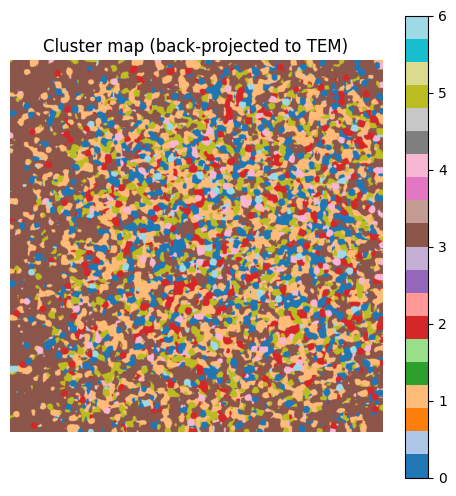

In [37]:
import pandas as pd

df_7_z = pd.read_parquet("gaussian_larger_patch.parquet")

labels = df_7_z["clustered"].to_numpy().ravel()
positions = get_positions(image, 64, 16)
prob_maps = reconstruct_soft_map(
    labels, positions, image.shape, 64, 16
)
hard_label_map = np.argmax(prob_maps, axis=-1).astype(np.uint8)
#label_img = label_to_image(image, prob_maps, positions)
confidence_map = np.max(prob_maps, axis=-1)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(hard_label_map, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

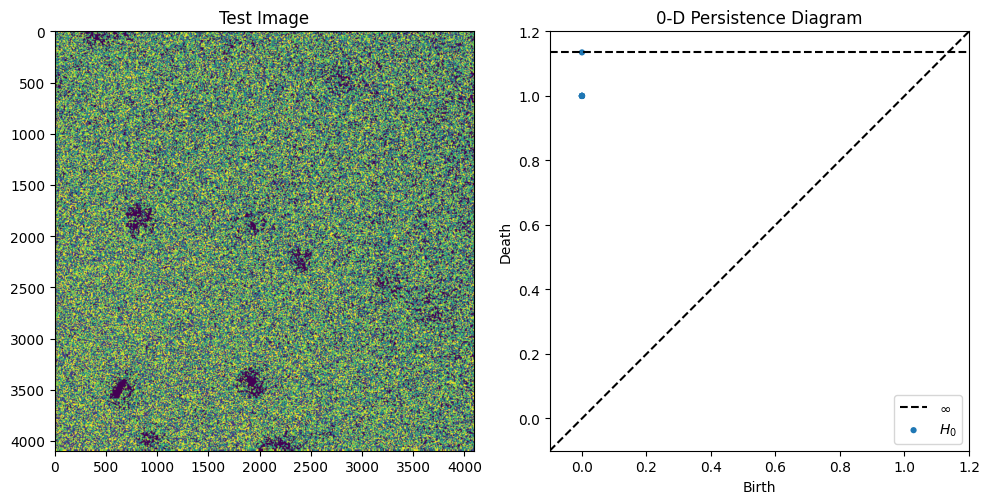

In [9]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img

mask = ((label_img == 1)).astype(np.uint8)

dgm = lower_star_img(mask)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(label_img)
plt.title("Test Image")
plt.subplot(122)
plot_diagrams(dgm)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.neighbors import KernelDensity
import numpy as np
dgm = dgm[np.isfinite(dgm[:, 1])]

# Treat each (birth, death) pair as a 2D point
points = np.column_stack([dgm[:, 0], dgm[:, 1]])

# Estimate density in persistence space
kde = KernelDensity(bandwidth=0.02).fit(points)
log_density = kde.score_samples(points)

# Keep only points in high-density regions
threshold = np.percentile(log_density, 30)  # tune this
filtered = dgm[log_density > threshold]

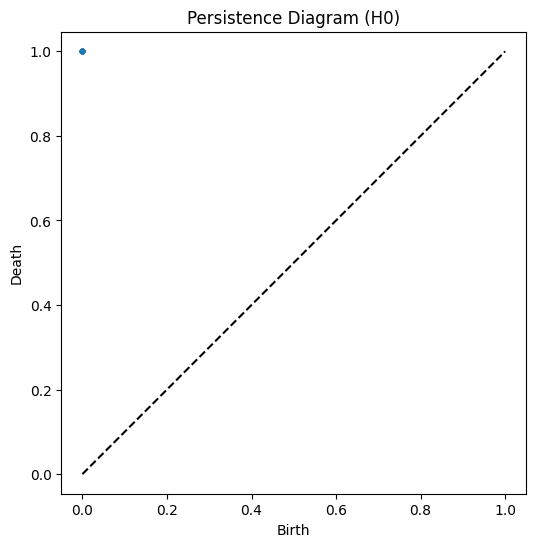